# Урок 6.2. Значения листьев: шаг Ньютона

**Интерактивная версия:** `lessons/lesson_6_2/web/index.html`

1. Ручной расчёт первой итерации на восьми точках.
2. Шаг Ньютона против точного минимума и против среднего псевдо-остатков.
3. Влияние на обучение: три способа задать листья.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from gbcourse import datasets, GBClassifier, RegressionTree
from gbcourse.metrics import log_loss
from gbcourse.plotting import use_course_style

use_course_style()
sig = lambda F: 1 / (1 + np.exp(-F))

## 1. Первая итерация вручную

In [2]:
X, y = datasets.toy_classification()
x = X[:, 0]
F0 = np.log(y.mean() / (1 - y.mean()))
p = sig(np.full(8, F0))
r, h = y - p, p * (1 - p)
print("F0 =", F0, "| псевдо-остатки:", r, "| гессианы:", h)
for t in (x[:-1] + x[1:]) / 2:
    L, R = r[x <= t], r[x > t]
    print(f"порог {t}: выигрыш {len(L) * len(R) / 8 * (L.mean() - R.mean()) ** 2:.3f}")
left = x <= 3.5
g_left = r[left].sum() / h[left].sum()
g_right = r[~left].sum() / h[~left].sum()
print(f"листья: {g_left} и {g_right}")
m = GBClassifier(n_estimators=1, learning_rate=1.0, max_depth=1).fit(X, y)
tr = m.trees_[0][0]
print("gbcourse:", tr.nodes[tr.nodes[0].left].value, tr.nodes[tr.nodes[0].right].value)

F0 = 0.0 | псевдо-остатки: [-0.5 -0.5 -0.5  0.5 -0.5  0.5  0.5  0.5] | гессианы: [0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25]
порог 1.5: выигрыш 0.286
порог 2.5: выигрыш 0.667
порог 3.5: выигрыш 1.200
порог 4.5: выигрыш 0.500
порог 5.5: выигрыш 1.200
порог 6.5: выигрыш 0.667
порог 7.5: выигрыш 0.286
листья: -2.0 и 1.2
gbcourse: -2.0 1.2


## 2. Ньютон против точного минимума

In [3]:
def exact_leaf(y_leaf, F_leaf):
    f = lambda g: np.sum(sig(F_leaf + g) - y_leaf)
    return brentq(f, -30, 30)


rng = np.random.default_rng(0)
print(" n  |  точный γ | Ньютон | среднее r")
for n in (5, 20, 100):
    F_leaf = rng.normal(0.5, 1.0, n)
    y_leaf = (rng.random(n) < 0.3).astype(float)
    pp = sig(F_leaf)
    # в «чистом» листе (все объекты одного класса) точный минимум уходит в ±∞
    exact = f"{exact_leaf(y_leaf, F_leaf):+8.4f}" if 0 < y_leaf.mean() < 1 else "     ±∞ "
    print(f"{n:3d} | {exact} | {np.sum(y_leaf - pp) / np.sum(pp * (1 - pp)):+.4f} | {np.mean(y_leaf - pp):+.4f}")

 n  |  точный γ | Ньютон | среднее r
  5 |      ±∞  | -2.7753 | -0.6276
 20 |  -2.2247 | -1.9061 | -0.4115
100 |  -1.8493 | -1.8360 | -0.3602


## 3. Три способа задать листья

среднее псевдо-остатков : лучший log-loss теста 0.3020 на итерации 150
шаг Ньютона             : лучший log-loss теста 0.2756 на итерации 55


точный минимум          : лучший log-loss теста 0.2766 на итерации 33


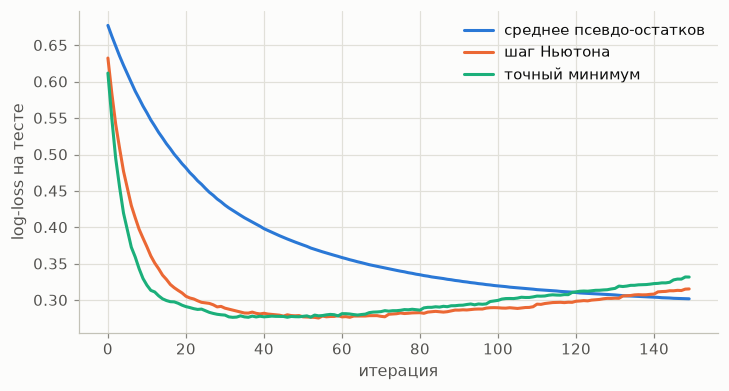

In [4]:
Xc, yc = datasets.classification_2d(kind="moons", n=400, noise=0.3, seed=64)
X_tr, X_te, y_tr, y_te = datasets.train_test_split(Xc, yc, test_size=0.3, seed=0)


def boost(mode, M=150, nu=0.1):
    F, F_te = np.zeros(len(y_tr)), np.zeros(len(y_te))
    curve = []
    for _ in range(M):
        pp = sig(F)
        t = RegressionTree(max_depth=2).fit(X_tr, -(y_tr - pp))
        for leaf in t.leaves:
            rows = leaf.rows
            if mode == "newton":
                leaf.value = np.sum(y_tr[rows] - pp[rows]) / max(np.sum(pp[rows] * (1 - pp[rows])), 1e-12)
            elif mode == "exact":
                if 0 < y_tr[rows].mean() < 1:
                    leaf.value = exact_leaf(y_tr[rows], F[rows])
                else:
                    leaf.value = np.sum(y_tr[rows] - pp[rows]) / max(np.sum(pp[rows] * (1 - pp[rows])), 1e-12)
        t.refresh_values()
        F += nu * t.predict(X_tr)
        F_te += nu * t.predict(X_te)
        curve.append(log_loss(y_te, sig(F_te)))
    return curve


fig, ax = plt.subplots(figsize=(7.5, 3.8))
for mode, label in (("mean", "среднее псевдо-остатков"), ("newton", "шаг Ньютона"), ("exact", "точный минимум")):
    c = boost(mode)
    ax.plot(c, label=label)
    print(f"{label:24s}: лучший log-loss теста {min(c):.4f} на итерации {int(np.argmin(c)) + 1}")
ax.set(xlabel="итерация", ylabel="log-loss на тесте")
ax.legend()
plt.show()

## Упражнения

1. Вычислите вручную значения листьев второй итерации (ν = 1) на восьми точках.
2. Сделайте два шага Ньютона для правого листа первой итерации. Насколько ближе к log 4?

Решения: `python lessons/lesson_6_2/exercises/solutions.py`.